# Imports

In [185]:

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import time
import os
import ast
import torch
import json
from PIL import Image
from tqdm.notebook import tqdm
from scipy.stats import entropy
from captum.attr import (
    IntegratedGradients
)

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

device = "cuda" if torch.cuda.is_available() else "cpu"

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

nltk.download('punkt')


[nltk_data] Downloading package punkt to /home/aysel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/aysel/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /home/aysel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Load Metadata

In [186]:
BASE_DIR = os.path.join("TFE_Data")
DATASETS_DIR = os.path.join(BASE_DIR, "Datasets")

df_text = pd.read_pickle(f"{DATASETS_DIR}/df_Flickr8k.pkl")

captions = []
caption_image_map = []

for _, row in df_text.iterrows():
    img = row["image_name"]
    for cap in row["captions"]:
        captions.append(cap)
        caption_image_map.append(img)

images = df_text["image_name"].tolist()

# Map image filename → index (0–8090)
image_to_idx = {img: idx for idx, img in enumerate(images)}

# For each caption, store the image index it belongs to
caption_to_image_idx = [image_to_idx[img] for img in caption_image_map]



df_retr_res = pd.read_csv("retrieval_projection_results/retrieval_results.csv")

# Convert stringified dicts → real dicts
for col in ["i2t", "t2i", "m2t", "m2i", "eff_i2t", "eff_t2i", "eff_m2t", "eff_m2i"]:
    df_retr_res[col] = df_retr_res[col].apply(ast.literal_eval)

# Extract R@1
df_retr_res["i2t_R@1"] = df_retr_res["i2t"].apply(lambda d: d["R@1"])
df_retr_res["t2i_R@1"] = df_retr_res["t2i"].apply(lambda d: d["R@1"])

# Remove invalid projection rows
df_retr_res = df_retr_res[df_retr_res["projection"] != "random"]

print(df_retr_res.head())

# Keep only rows with valid embeddings
valid_rows = []
for idx, row in df_retr_res.iterrows():
    v, t, proj = row["vision_model"], row["text_model"], row["projection"]
    Xv_path = f"projected_embeddings/{v}_{t}_{proj}_Xv.npy"
    Xt_path = f"projected_embeddings/{v}_{t}_{proj}_Xt.npy"
    if os.path.exists(Xv_path) and os.path.exists(Xt_path):
        Xv = np.load(Xv_path)
        Xt = np.load(Xt_path)
        if Xv.shape[0] == 8091 and Xt.shape[0] == 40455:
            valid_rows.append(idx)

df_retr_res = df_retr_res.loc[valid_rows]

best_i2t_cfg = df_retr_res.loc[df_retr_res["i2t_R@1"].idxmax()]
best_t2i_cfg = df_retr_res.loc[df_retr_res["t2i_R@1"].idxmax()]

# 8091 images, 40455 captions
gt_i2t = {i: list(range(i*5, i*5 + 5)) for i in range(8091)}
gt_t2i = {j: j // 5 for j in range(40455)}


   vision_model text_model projection  fusion  \
4  mobilenet_v3    roberta       wcca  concat   
5  mobilenet_v3    roberta       wcca     add   
6  mobilenet_v3    roberta       wcca   gated   
7  mobilenet_v3    roberta       wcca     mul   
8  mobilenet_v3    roberta       cpca  concat   

                                                 i2t  \
4  {'R@1': 0.012235817575083427, 'R@5': 0.0461006...   
5  {'R@1': 0.012235817575083427, 'R@5': 0.0461006...   
6  {'R@1': 0.012235817575083427, 'R@5': 0.0461006...   
7  {'R@1': 0.012235817575083427, 'R@5': 0.0461006...   
8  {'R@1': 0.005314547027561488, 'R@5': 0.0184155...   

                                                 t2i  \
4  {'R@1': 0.0004449388209121246, 'R@5': 0.001903...   
5  {'R@1': 0.0004449388209121246, 'R@5': 0.001903...   
6  {'R@1': 0.0004449388209121246, 'R@5': 0.001903...   
7  {'R@1': 0.0004449388209121246, 'R@5': 0.001903...   
8  {'R@1': 0.0011123470522803114, 'R@5': 0.003287...   

                               

# Load RAG Model

In [187]:
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
rag_model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base").to(device)


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


# RAG Prompt and Generate Caption

In [188]:
def build_rag_prompt(captions):
    prompt = (
        "Rewrite the following captions into a single, coherent, human-like description.\n\n"
        + "\n".join([f"- {c}" for c in captions])
        + "\n\nRefined caption:"
    )
    return prompt

def rag_refine(captions):
    prompt = build_rag_prompt(captions)
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    output = rag_model.generate(
        **inputs,
        max_length=128,
        num_beams=5,
        temperature=0.7
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)


# Retrieve Candidates

In [189]:
def fix_projection_matrix(W):
    # If W is (shared_dim, text_dim), OK
    # If W is (text_dim, shared_dim), transpose it
    if W.shape[0] < W.shape[1]:
        # likely (128 × 768)
        return W
    else:
        # likely (768 × 128)
        return W.T

def load_projection_model(cfg):
    Wv = np.load(f"projection_matrices/Wv_{cfg['vision_model']}_{cfg['text_model']}_{cfg['projection']}.npy")
    Wt = np.load(f"projection_matrices/Wt_{cfg['vision_model']}_{cfg['text_model']}_{cfg['projection']}.npy")

    Wv = fix_projection_matrix(Wv)
    Wt = fix_projection_matrix(Wt)

    proj_v = torch.tensor(Wv, dtype=torch.float32).to(device)
    proj_t = torch.tensor(Wt, dtype=torch.float32).to(device)

    return proj_v, proj_t


def load_projected_embeddings(cfg):
    v = cfg["vision_model"]
    t = cfg["text_model"]
    proj = cfg["projection"]
    Xv = np.load(f"projected_embeddings/{v}_{t}_{proj}_Xv.npy")
    Xt = np.load(f"projected_embeddings/{v}_{t}_{proj}_Xt.npy")
    return Xv, Xt

Xv_best_i2t, Xt_best_i2t = load_projected_embeddings(best_i2t_cfg)
Xv_best_t2i, Xt_best_t2i = load_projected_embeddings(best_t2i_cfg)

# Load CLIP + OpenCLIP embeddings
clip_vision = np.load("TFE_Data/Results_Multimodal/Flickr8k/clip/vision_embeddings.npy")
clip_text   = np.load("TFE_Data/Results_Multimodal/Flickr8k/clip/text_embeddings.npy")

openclip_vision = np.load("TFE_Data/Results_Multimodal/Flickr8k/openclip_l14/vision_embeddings.npy")
openclip_text   = np.load("TFE_Data/Results_Multimodal/Flickr8k/openclip_l14/text_embeddings.npy")


In [190]:
def get_top50(model_name, image_index):
    cfg = MODEL_CONFIGS[model_name]

    if model_name in ["clip", "openclip"]:
        Xv = cfg["vision"]
        Xt = cfg["text"]
    else:
        Xv, Xt = load_projected_embeddings(cfg)

    sims = cosine_similarity(Xv[image_index].reshape(1, -1), Xt)[0]
    top50_idx = np.argsort(sims)[::-1][:50]

    # Return captions + embeddings + image embedding
    return [captions[i] for i in top50_idx], Xt[top50_idx], Xv[image_index]


# Evaluation Metrics

In [191]:
# ============================
# TEXT ENCODER + IG WRAPPERS
# ============================

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn as nn

class TextWrapper(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(self, input_ids, attention_mask=None):
        out = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
            return_dict=True
        )
        cls = out.last_hidden_state[:, 0, :]
        return self.head(cls)

    def get_input_embeddings(self):
        return self.backbone.get_input_embeddings()

class EmbeddingWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.embeddings = model.get_input_embeddings()

    def forward(self, embeddings, attention_mask=None):
        outputs = self.model(
            inputs_embeds=embeddings,
            attention_mask=attention_mask
        )
        return outputs.logits

def load_bert(device):
    tok = AutoTokenizer.from_pretrained("bert-base-uncased")
    model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    ).to(device).eval()
    backbone = model.bert
    return model, tok, backbone

text_model, text_tok, text_backbone = load_bert(device)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [192]:
def get_text_cls_embedding(caption, tok, backbone):
    batch = tok(
        caption,
        truncation=True,
        padding="max_length",
        max_length=64,
        return_tensors="pt"
    ).to(device)

    out = backbone(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        output_hidden_states=True,
        return_dict=True
    )

    cls = out.last_hidden_state[:, 0, :]   # (1, hidden_dim)
    return cls

def project_text_embedding(cls_emb, proj_t):
    return (cls_emb @ proj_t.T)  # shape (1, shared_dim)



In [193]:
def embed_refined_caption(refined_caption, Xt, captions):
    if refined_caption in captions:
        idx = captions.index(refined_caption)
        return Xt[idx]
    else:
        # fallback: use centroid of top50
        return None

def ig_image_projection(img_emb, proj_v):
    img_tensor = torch.tensor(img_emb, dtype=torch.float32).to(device).unsqueeze(0)

    def forward_fn(x):
        out = (x @ proj_v.T).norm()
        return out.unsqueeze(0)   # <-- FIX: make it shape (1,)

    ig = IntegratedGradients(forward_fn)
    return ig.attribute(img_tensor).cpu().numpy()

def ig_text_projection(caption, tok, backbone, proj_t):
    batch = tok(
        caption,
        truncation=True,
        padding="max_length",
        max_length=64,
        return_tensors="pt"
    ).to(device)

    out = backbone(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        output_hidden_states=True,
        return_dict=True
    )

    cls_emb = out.last_hidden_state[:, 0, :]   # (1 × 768)

    def forward_fn(x):
        out = (x @ proj_t.T).norm()   # (1×768) @ (768×128)
        return out.unsqueeze(0)

    ig = IntegratedGradients(forward_fn)
    return ig.attribute(cls_emb).detach().cpu().numpy()


def ig_image_clip(img_emb):
    return img_emb  # no projection → IG not meaningful

def explain_ig(model, img, label):
    ig = IntegratedGradients(model)
    return ig.attribute(img.unsqueeze(0), target=label)

In [212]:
# Cosine Similarity Improvement
def cosine_vec(a, b):
    a = a.reshape(-1)
    b = b.reshape(-1)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)

def evaluate_cosine(image_emb, top50_embs, refined_emb):
    original_mean = np.mean([cosine_vec(image_emb, e) for e in top50_embs])
    refined_score = cosine_vec(image_emb, refined_emb)

    return original_mean, refined_score


In [213]:
# Caption-to-Caption Similarity

def evaluate_centroid_similarity(top50_embs, refined_emb):
    centroid = np.mean(top50_embs, axis=0)
    dist_original = np.mean([np.linalg.norm(e - centroid) for e in top50_embs])
    dist_refined = np.linalg.norm(refined_emb - centroid)
    return dist_original, dist_refined


In [214]:
# Diversity Reduction

def caption_entropy(captions):
    words = " ".join(captions).split()
    _, counts = np.unique(words, return_counts=True)
    return entropy(counts)

def evaluate_entropy(top50, refined):
    return caption_entropy(top50), caption_entropy([refined])


In [215]:
# Multimodal Consistency

def cross_modal_consistency(ig_img, ig_txt):
    a = ig_img.flatten()
    b = ig_txt.flatten()
    return cosine_vec(a, b)


In [216]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk

def compute_bleu(gt_caps, refined_caption):
    smoothie = SmoothingFunction().method4

    # Tokenize using NLTK (Option A)
    refs = [nltk.word_tokenize(cap.lower()) for cap in gt_caps]
    hyp  = nltk.word_tokenize(refined_caption.lower())

    bleu = sentence_bleu(refs, hyp, smoothing_function=smoothie)
    return bleu


# Pipeline

In [217]:
MODEL_CONFIGS = {
    "ours_best_i2t": best_i2t_cfg,
    "ours_best_t2i": best_t2i_cfg,
    "clip": {
        "vision": clip_vision,
        "text": clip_text,
        "type": "clip"
    },
    "openclip": {
        "vision": openclip_vision,
        "text": openclip_text,
        "type": "openclip"
    }
}


In [234]:
def evaluate_rag(model_name, image_index):

    # 1. Retrieve top-50
    top50_caps, top50_embs, img_emb = get_top50(model_name, image_index)

    # 2. RAG refinement
    refined_caption = rag_refine(top50_caps)

    # 3. Embed refined caption
    refined_emb = embed_refined_caption(refined_caption, Xt_best_i2t, captions)
    if refined_emb is None:
        refined_emb = np.mean(top50_embs, axis=0)

    # 4. Metrics
    """cos_orig, cos_ref = evaluate_cosine(img_emb, top50_embs, refined_emb)"""
    
    # Ensure all embeddings have the same dimension
    if img_emb.shape[0] != refined_emb.shape[0]:
        # fallback: project refined into image space by averaging top50
        refined_emb = np.mean(top50_embs, axis=0)

    cos_orig, cos_ref = evaluate_cosine(img_emb, top50_embs, refined_emb)


    cent_orig, cent_ref = evaluate_centroid_similarity(top50_embs, refined_emb)
    ent_orig, ent_ref = evaluate_entropy(top50_caps, refined_caption)

    """
    # 5. IG(image)
    proj_v, proj_t = load_projection_model(MODEL_CONFIGS[model_name])
    
    # Project image embedding into shared space
    img_emb_t = torch.tensor(img_emb, dtype=torch.float32, device=device)
    img_proj = (img_emb_t @ proj_v).cpu().numpy()


    # Project text embedding into shared space
    txt_cls = get_text_cls_embedding(refined_caption, text_tok, text_backbone)
    txt_cls_t = txt_cls.squeeze(0)  # (768,)
    txt_proj = (txt_cls_t @ proj_t.T).detach().cpu().numpy().flatten()


    # Multimodal consistency
    consistency = cosine_vec(img_proj, txt_proj)
    """
    # 7. BLEU score
    gt_caps = get_ground_truth_captions(image_index)
    bleu = compute_bleu(gt_caps, refined_caption)

    return {
        "model": model_name,
        "refined_caption": refined_caption,
        "cosine_original": cos_orig,
        "cosine_refined": cos_ref,
        "centroid_original": cent_orig,
        "centroid_refined": cent_ref,
        "entropy_original": ent_orig,
        "entropy_refined": ent_ref,
        #"multimodal_consistency": consistency
        "bleu": bleu
    }


In [235]:
human_eval = pd.DataFrame(columns=[
    "image_id", "refined_caption", "relevance", "fluency",
    "descriptiveness", "correctness"
])


In [236]:
def interpret_results(res):
    print("Refined Caption:", res["refined_caption"])
    print("\nCosine Similarity:")
    print("  Original:", res["cosine_original"])
    print("  Refined :", res["cosine_refined"])

    print("\nCentroid Distance:")
    print("  Original:", res["centroid_original"])
    print("  Refined :", res["centroid_refined"])

    print("\nEntropy:")
    print("  Original:", res["entropy_original"])
    print("  Refined :", res["entropy_refined"])

    print("\nMultimodal Consistency:", res["multimodal_consistency"])


In [237]:
from PIL import Image
import matplotlib.pyplot as plt
def show_image(image_index):
    img_name = images[image_index]

    img_path = os.path.join(
        BASE_DIR,
        "Flickr8k",
        "Images",
        "Flicker8k_Dataset",
        img_name
    )

    img = Image.open(img_path)
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image #{image_index}: {img_name}")
    plt.show()
    
def get_ground_truth_captions(image_index):
    start = image_index * 5
    end = start + 5
    return captions[start:end]

import spacy
nlp = spacy.load("en_core_web_sm")

def extract_concepts(text):
    doc = nlp(text.lower())
    nouns = {token.lemma_ for token in doc if token.pos_ == "NOUN"}
    verbs = {token.lemma_ for token in doc if token.pos_ == "VERB"}
    adjs  = {token.lemma_ for token in doc if token.pos_ == "ADJ"}
    return nouns, verbs, adjs

def compare_captions(gt_caps, refined_caption):
    gt_text = " ".join(gt_caps)
    gt_n, gt_v, gt_a = extract_concepts(gt_text)
    ref_n, ref_v, ref_a = extract_concepts(refined_caption)

    return {
        "missing_nouns": list(gt_n - ref_n),
        "added_nouns":   list(ref_n - gt_n),
        "missing_verbs": list(gt_v - ref_v),
        "added_verbs":   list(ref_v - gt_v),
        "missing_adjs":  list(gt_a - ref_a),
        "added_adjs":    list(ref_a - gt_a),
    }
   
def print_top50(top50_caps):
    print("\n=== Top‑50 Retrieved Captions ===\n")
    for i, cap in enumerate(top50_caps):
        print(f"{i+1:02d}. {cap}")
        
def print_refined(refined_caption):
    print("\n=== RAG‑Refined Caption ===\n")
    print(refined_caption)

def display_rag_for_all_models(image_index):
    # Show the image once
    show_image(image_index)
    
    gt_caps = get_ground_truth_captions(image_index)
    for i, cap in enumerate(gt_caps):
        print(f"{i+1}. {cap}")

    results = []

    for model_name in MODEL_CONFIGS.keys():
        print("\n" + "="*80)
        print(f"MODEL: {model_name}")
        print("="*80)

        # Retrieve top‑50
        top50_caps, top50_embs, img_emb = get_top50(model_name, image_index)

        # RAG refinement
        refined_caption = rag_refine(top50_caps)
        
        # Print top‑5
        print("\nTop‑5 Retrieved Captions:")
        for i, cap in enumerate(top50_caps[:5]):
            print(f"{i+1:02d}. {cap}")

        # Print refined caption
        print("\nRefined Caption:")
        print(refined_caption)
        
        # Semantic difference analysis
        diff = compare_captions(gt_caps, refined_caption)

        print("\n--- Semantic Differences ---")
        for k, v in diff.items():
            print(f"{k}: {v}")

        # Run full evaluation
        res = evaluate_rag(model_name, image_index)
        res["semantic_diff"] = diff
        results.append(res)

    return pd.DataFrame(results)

def display_rag_for_all_models_w_captions(image_index):
    # Show the image once
    show_image(image_index)

    results = []

    for model_name in MODEL_CONFIGS.keys():
        print("\n" + "="*80)
        print(f"MODEL: {model_name}")
        print("="*80)

        # Retrieve top‑50
        top50_caps, top50_embs, img_emb = get_top50(model_name, image_index)

        # RAG refinement
        refined_caption = rag_refine(top50_caps)

        # Print top‑50
        print("\nTop‑50 Retrieved Captions:")
        for i, cap in enumerate(top50_caps):
            print(f"{i+1:02d}. {cap}")

        # Print refined caption
        print("\nRefined Caption:")
        print(refined_caption)

        # Run full evaluation
        res = evaluate_rag(model_name, image_index)
        results.append(res)

    return pd.DataFrame(results)

def collect_image_results(image_index):
    image_path = images[image_index]  # or your full path logic

    gt_caps = get_ground_truth_captions(image_index)

    image_record = {
        "image_index": image_index,
        "image_path": image_path,
        "ground_truth": gt_caps,
        "models": {}
    }

    for model_name in MODEL_CONFIGS.keys():
        top50_caps, top50_embs, img_emb = get_top50(model_name, image_index)
        refined_caption = rag_refine(top50_caps)

        # semantic diff
        diff = compare_captions(gt_caps, refined_caption)

        # metrics
        metrics = evaluate_rag(model_name, image_index)

        image_record["models"][model_name] = {
            "top50": top50_caps,
            "refined": refined_caption,
            "semantic_diff": diff,
            "metrics": metrics
        }

    return image_record


# Execution

In [ ]:
STRESS_TEST_IMAGES = [
    os.path.join(
        BASE_DIR,
        "Flickr8k",
        "Images",
        "Flicker8k_Dataset",
        fname
    )
    for fname in [
        "107582366_d86f2d3347.jpg",
        "127450902_533ceeddfc.jpg",
        "112178718_87270d9b4d.jpg",
        "141755290_4b954529f3.jpg",
        "171488318_fb26af58e2.jpg",
        "240583223_e26e17ee96.jpg",
        "241346317_be3f07bd2e.jpg",
        "911795495_342bb15b97.jpg",
        "2452686995_621878f561.jpg",
        "97577988_65e2eae14a.jpg"
    ]
]

STRESS_IMAGE_INDEXES = []
STRESS_TEXT_INDEXES = []
STRESS_TEXTS = []

for full_path in STRESS_TEST_IMAGES:
    fname = os.path.basename(full_path)   # <-- FIX: strip directory
    idx = image_to_idx[fname]             # now it matches the dict keys

    # Each image has 5 captions stored sequentially
    cap_idx = idx * 5

    STRESS_IMAGE_INDEXES.append(idx)
    STRESS_TEXT_INDEXES.append(cap_idx)
    STRESS_TEXTS.append(captions[cap_idx])
    

In [238]:
all_data = []

for idx in STRESS_IMAGE_INDEXES:
    print(f"Processing image {idx}")
    record = collect_image_results(idx)
    all_data.append(record)


Processing image 56
Processing image 231
Processing image 114
Processing image 418
Processing image 676
Processing image 1737
Processing image 1777
Processing image 8015
Processing image 1942
Processing image 8074


TypeError: Object of type float32 is not JSON serializable

In [240]:

import json
def to_serializable(obj):
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().numpy().tolist()
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    return obj

serializable_data = to_serializable(all_data)

with open("stress_test_rag_results.json", "w") as f:
    json.dump(serializable_data, f, indent=2)


with open("stress_test_rag_results.json", "w") as f:
    json.dump(serializable_data, f, indent=2)
    
import pickle

with open("stress_test_rag_results.pkl", "wb") as f:
    pickle.dump(all_data, f)



In [ ]:
results = []
image_index = 123

for model_name in MODEL_CONFIGS.keys():
    print("Evaluating:", model_name)
    res = evaluate_rag(model_name, image_index=image_index)
    results.append(res)

pd.DataFrame(results)


Evaluating: ours_best_i2t
Evaluating: ours_best_t2i
Evaluating: clip
Evaluating: openclip


,model,refined_caption,cosine_original,cosine_refined,centroid_original,centroid_refined,entropy_original,entropy_refined,bleu
0,ours_best_i2t,A young boy in a blue shirt is standing on the...,0.734453,0.784130,3.796502,0.0,4.163900,2.736339,0.140849
1,ours_best_t2i,A young boy in a blue shirt is standing on the...,0.734453,0.784130,3.796502,0.0,4.163900,2.736339,0.140849
2,clip,A young boy runs along a boardwalk towards a p...,0.332665,0.416133,0.594901,0.0,4.286227,3.295593,0.050284
3,openclip,A little boy in a striped t-shirt walking alon...,0.264647,0.360663,0.676770,0.0,4.225677,2.369382,0.356551




######## IMAGE 56 ########


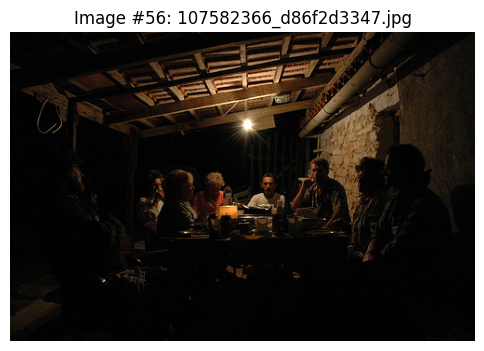

1. A group of eight people are gathered around a table at night .
2. A group of people gathered around in the dark .
3. A group of people sit around a table outside on a porch at night .
4. A group of people sit outdoors together at night .
5. A group of people sitting at a table in a darkened room .

MODEL: ours_best_i2t

Top‑5 Retrieved Captions:
01. Four people are sitting at a table in front of an audience .
02. Four people are meeting around table in a modern decorated room .
03. People are sitting at square tables in a red room .
04. People are gathered at a bar .
05. A group of people sitting at a table in a darkened room .

Refined Caption:
Four people are sitting at a table in front of an audience .

--- Semantic Differences ---
missing_nouns: ['porch', 'room', 'group', 'night', 'dark']
added_nouns: ['front', 'audience']
missing_verbs: ['darken', 'gather']
added_verbs: []
missing_adjs: []
added_adjs: []

MODEL: ours_best_t2i

Top‑5 Retrieved Captions:
01. Four people are sitti

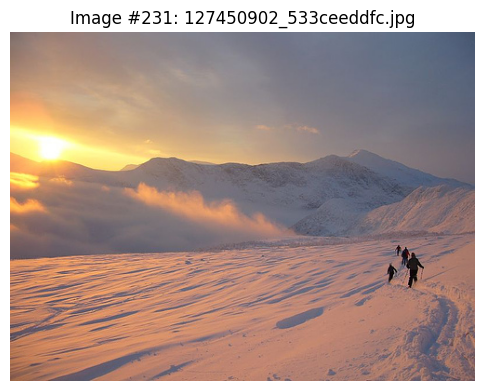

1. A winter landscape with four people walking in the snow .
2. Beautiful snowy landscape with people treading through the snow .
3. Cross-country skiers are traveling towards the mountains at sunset .
4. Four people walking across thick snow during a sunset .
5. The sun is almost behind the snowy mountains .

MODEL: ours_best_i2t

Top‑5 Retrieved Captions:
01. a man enjoying the view from top of a mountain
02. a skier skiing down a snowy mountainside
03. A skier takes to great heights on a snow-covered mountain slope .
04. The skier is looking at the snowcapped mountains .
05. A beautiful view of the mountains on a snowy day .

Refined Caption:
A skier skiing down a snowy mountainside .

--- Semantic Differences ---
missing_nouns: ['mountain', 'winter', 'people', 'landscape', 'snow', 'sunset', 'sun']
added_nouns: ['mountainside']
missing_verbs: ['tread', 'travel', 'walk']
added_verbs: ['ski']
missing_adjs: ['thick', 'country', '-', 'cross', 'beautiful']
added_adjs: []

MODEL: ours_bes

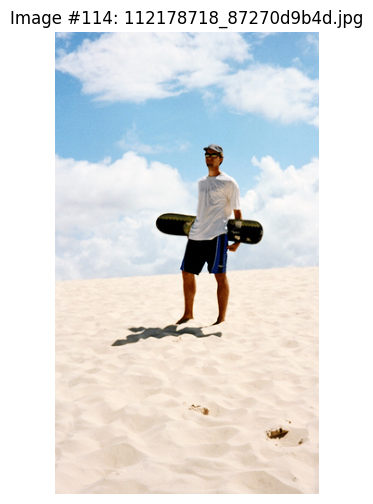

1. A guy stands in the sand with a snowboard behind him .
2. A man holds a surfboard on the beach .
3. a man holds his snowboard in the sand .
4. A man with his surfboard stands in the sand .
5. Man is standing on white sand and holding a snowboard .

MODEL: ours_best_i2t

Top‑5 Retrieved Captions:
01. A man tosses a boy into the air at the beach .
02. A teenager in striped shorts is leaping into the air on the beach .
03. A teenage boy is doing a back flip in midair on the beach .
04. A boy does a flip on the beach .
05. The boy on a skateboard is jumping through the air .

Refined Caption:
A young boy jumps into the air at a beach .

--- Semantic Differences ---
missing_nouns: ['man', 'surfboard', 'guy', 'snowboard', 'sand']
added_nouns: ['air', 'boy']
missing_verbs: ['hold', 'stand']
added_verbs: ['jump']
missing_adjs: ['white']
added_adjs: ['young']

MODEL: ours_best_t2i

Top‑5 Retrieved Captions:
01. A man tosses a boy into the air at the beach .
02. A teenager in striped shorts i

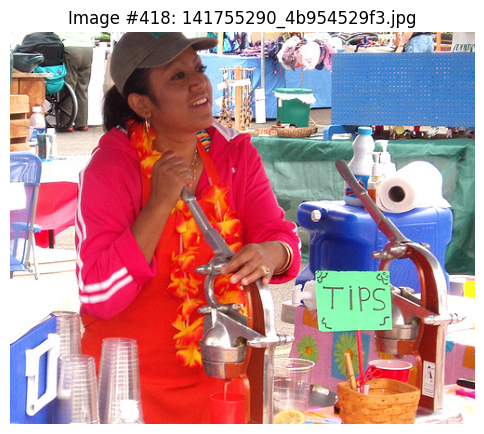

1. A vendor in all pink and red clothing is preparing her wears while looking forward .
2. A woman in an red tracksuit squeezing lemons in a press .
3. A woman wearing a floral necklace makes a drink and smiles .
4. The lady is selling freshly squeezed lemonade .
5. The woman is squeezing juice to make drinks .

MODEL: ours_best_i2t

Top‑5 Retrieved Captions:
01. An Asian girl in a green hat and apron is serving drinks on a tray .
02. A child in period costume looking at a table with a bowl , cup , and a basket of apples .
03. A man holding plastic toys looks away while a man wearing a white hat smiles at the camera .
04. A young Chinese girl playing the drums with two chopsticks , a pot , and a blue plastic bowl .
05. A woman is holding a jar of mustard and a boy is looking at a tray of hamburgers .

Refined Caption:
A young girl in a green hat and apron is serving drinks on a tray . A man in a balloon hat and a grassy shirt is holding a try full of drink samples . A small child in gr

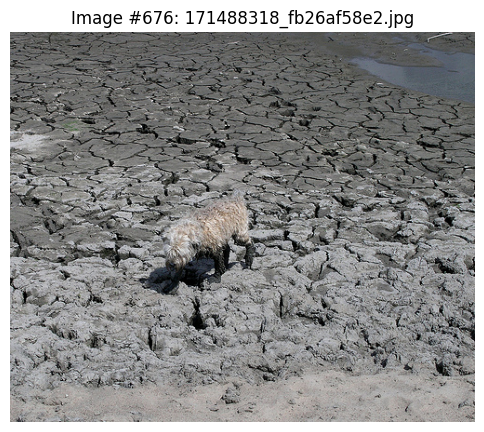

1. A dog is walking along some dry cracked earth .
2. A dog walking along a cracked and ashen surface .
3. A dog walking on mud flats .
4. A dog walks across the rocky ground .
5. A dog walks through some mud .

MODEL: ours_best_i2t

Top‑5 Retrieved Captions:
01. A dog runs overtop the dry earth .
02. a black dog runs through the dry grass .
03. A dirt dog runs down a muddy shore .
04. A dog is walking along some dry cracked earth .
05. A yellow dog digs in the sand near grass .

Refined Caption:
A dog runs overtop the dry earth .

--- Semantic Differences ---
missing_nouns: ['ground', 'surface', 'mud', 'flat']
added_nouns: ['run']
missing_verbs: ['crack', 'walk']
added_verbs: ['overtop']
missing_adjs: ['ashen', 'cracked', 'rocky']
added_adjs: []

MODEL: ours_best_t2i

Top‑5 Retrieved Captions:
01. A dog runs overtop the dry earth .
02. a black dog runs through the dry grass .
03. A dirt dog runs down a muddy shore .
04. A dog is walking along some dry cracked earth .
05. A yellow dog 

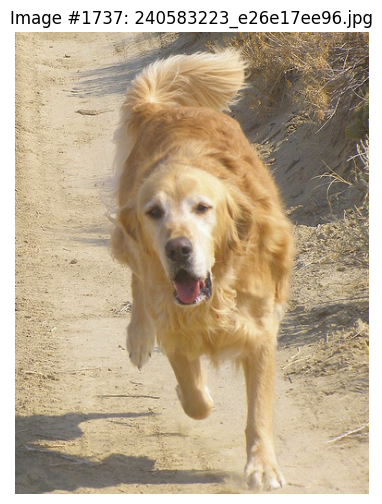

1. A brown dog is running on a dirt path .
2. A dog is running down a dirt path .
3. A running golden retriever
4. A yellow dog running down a sandy path .
5. The yellow dog is running on the dirt road .

MODEL: ours_best_i2t

Top‑5 Retrieved Captions:
01. A furry brown dog carries his toy in mouth outside .
02. A brown dogs licks its black nose .
03. A brown dog is licking its nose .
04. A large brown dog sniffs a small white dog 's behind .
05. A golden retriever nurses puppies .

Refined Caption:
Three dogs are outside , one licks the other 's nose . A brown dog is licking its nose . A brown dog is licking its nose . A brown dog is licking its nose . A brown dog is licking its nose . A brown dog is licking its nose . A brown dog is licking its nose . A brown dog is licking its nose . A brown dog is licking its nose . A brown dog is licking its nose . A brown dog is licking its nose 

--- Semantic Differences ---
missing_nouns: ['dirt', 'road', 'retriever', 'path']
added_nouns: ['nos

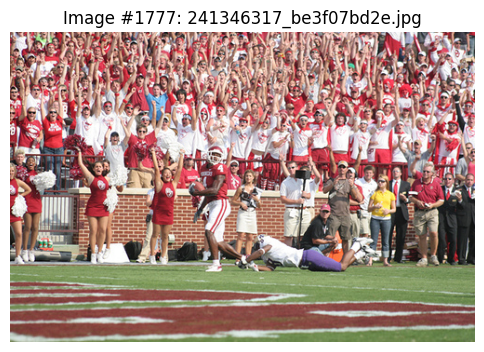

1. A crowd is standing and cheering at a football game .
2. A crowd of people watching a football game with a player wearing red and cheerleaders also wearing red .
3. A football player is grabbing the ankle of another player who is holding the ball .
4. An Oklahoma football player is about to score .
5. The fans at a football game cheer while the player runs towards the endzone .

MODEL: ours_best_i2t

Top‑5 Retrieved Captions:
01. Football players gather around the referees .
02. Two opposing hockey players make a play for the puck with opposing fans and team members watching .
03. Hockey players scramble in front of the goal .
04. Football players huddle and get ready for the game .
05. Football players in red congratulate each other as crowds in red cheer behind .

Refined Caption:
Three football players play a game while fans watch from the bleachers .

--- Semantic Differences ---
missing_nouns: ['ball', 'people', 'cheer', 'cheerleader', 'ankle', 'red', 'endzone', 'crowd']
added_

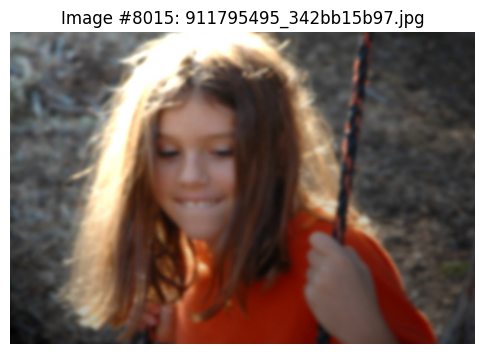

1. A girl sits on a swing .
2. A girl wearing an orange shirt holds onto poles and looks down .
3. A soft focus picture of a little girl wearing an orange sweater .
4. a young girl with long brown hair holding a black and red striped stick .
5. The girl in the red shirt smiles on the swing .

MODEL: ours_best_i2t

Top‑5 Retrieved Captions:
01. A redheaded girl with a turquoise jacket is swinging .
02. A young girl with brown hair is swinging on a swing in a swimming suit .
03. A young girl wearing a pink hat swinging on a swing set .
04. A young girl with blond hair holding onto a rail
05. The blonde haired woman is holding a black umbrella .

Refined Caption:
A young girl is swinging on a swing .

--- Semantic Differences ---
missing_nouns: ['pole', 'sweater', 'picture', 'focus', 'stick', 'shirt', 'hair']
added_nouns: []
missing_verbs: ['sit', 'strip', 'hold', 'wear', 'smile', 'look']
added_verbs: ['swing']
missing_adjs: ['orange', 'long', 'brown', 'red', 'little', 'soft', 'black']
ad

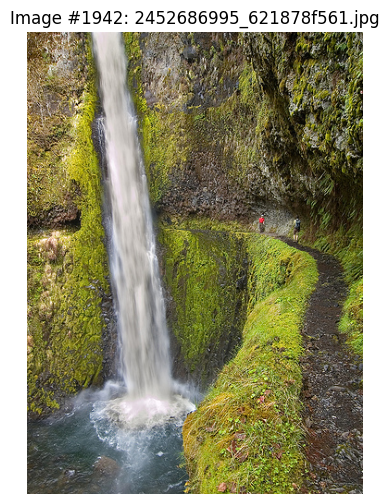

1. A beautiful waterfall with two people walking on the road beside it .
2. A beautiful waterfall flows down the side of a mossy rock wall .
3. A waterfall cascades into a shallow pool .
4. A waterfall splashes into a pool at the bottom of a steep grassy hill .
5. Two people travel down a path going though a woods with a giant waterfall .

MODEL: ours_best_i2t

Top‑5 Retrieved Captions:
01. A beautiful waterfall flows down the side of a mossy rock wall .
02. A waterfall splashes into a pool at the bottom of a steep grassy hill .
03. A waterfall cascades into a shallow pool .
04. Hikers cross a bridge over a fast moving stream and rocky scenery .
05. A person crosses the stream in front of a waterfall .

Refined Caption:
A waterfall flows down the side of a mossy rock wall . A waterfall cascades into a pool at the bottom of a steep grassy hill . A waterfall splashes into a pool at the bottom of a steep grassy hill . A person sits on a rock at the edge of a large waterfall . A person sur

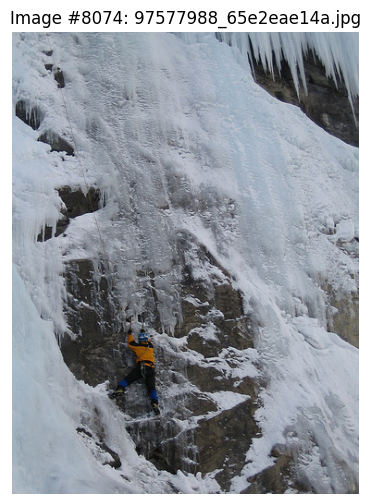

1. A man mountain climbing up an icy mountain .
2. An climber is ascending an ice covered rock face .
3. A person in orange climbs a sheer cliff face covered in snow and ice .
4. Person in a yellow jacket is climbing up snow covered rocks .
5. There is a climber scaling a snowy mountainside .

MODEL: ours_best_i2t

Top‑5 Retrieved Captions:
01. A person hiking at the foot of snowcapped mountains .
02. A solitary climber on snowy , high mountains .
03. A climber on a snowy mountain
04. A skier takes to great heights on a snow-covered mountain slope .
05. A snowy peak .

Refined Caption:
Someone hikes through a snowy mountain range .

--- Semantic Differences ---
missing_nouns: ['person', 'ice', 'climb', 'cliff', 'snow', 'man', 'jacket', 'mountainside', 'climber', 'face', 'rock']
added_nouns: ['range']
missing_verbs: ['cover', 'scale', 'ascend', 'be', 'climb']
added_verbs: ['hike']
missing_adjs: ['icy', 'yellow', 'sheer']
added_adjs: []

MODEL: ours_best_t2i

Top‑5 Retrieved Captions:
01

In [239]:
 
all_results = []

for idx in STRESS_IMAGE_INDEXES:
    print(f"\n\n######## IMAGE {idx} ########")
    df = display_rag_for_all_models(idx)
    df["image_index"] = idx
    all_results.append(df)

final_df = pd.concat(all_results, ignore_index=True)

